Initial EDA for the project 4 data

## customers ##

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv(r'C:\Users\tlext\Downloads\urbanshift_dataset\urbanshift_dataset\customers.csv')

data.head()

,customer_id,customer_name,customer_size,city,signup_date,account_manager,industry,payment_terms_days
0,CUST1000,Apex Retail Ltd,Mid-size Retailer,London,2022-06-13,Tom Bradley,Beauty,60
1,CUST1001,Blue Trading Ltd,Mid-size Retailer,London,2024-05-15,Mark Thompson,Books,30
2,CUST1002,Coast Direct Ltd,Small Retailer,Bristol,2022-11-02,James Wilson,Fashion,30
3,CUST1003,Delta Commerce Ltd,Small Retailer,Leeds,2024-06-28,Tom Bradley,Beauty,60
4,CUST1004,Echo Store Ltd,Small Retailer,Manchester,2022-06-28,Mark Thompson,Electronics,30


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   customer_id         120 non-null    object
 1   customer_name       120 non-null    object
 2   customer_size       120 non-null    object
 3   city                120 non-null    object
 4   signup_date         120 non-null    object
 5   account_manager     120 non-null    object
 6   industry            120 non-null    object
 7   payment_terms_days  120 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 7.6+ KB


In [3]:
data.describe()

,payment_terms_days
count,120.000000
mean,34.308333
std,11.844792
min,14.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,60.000000


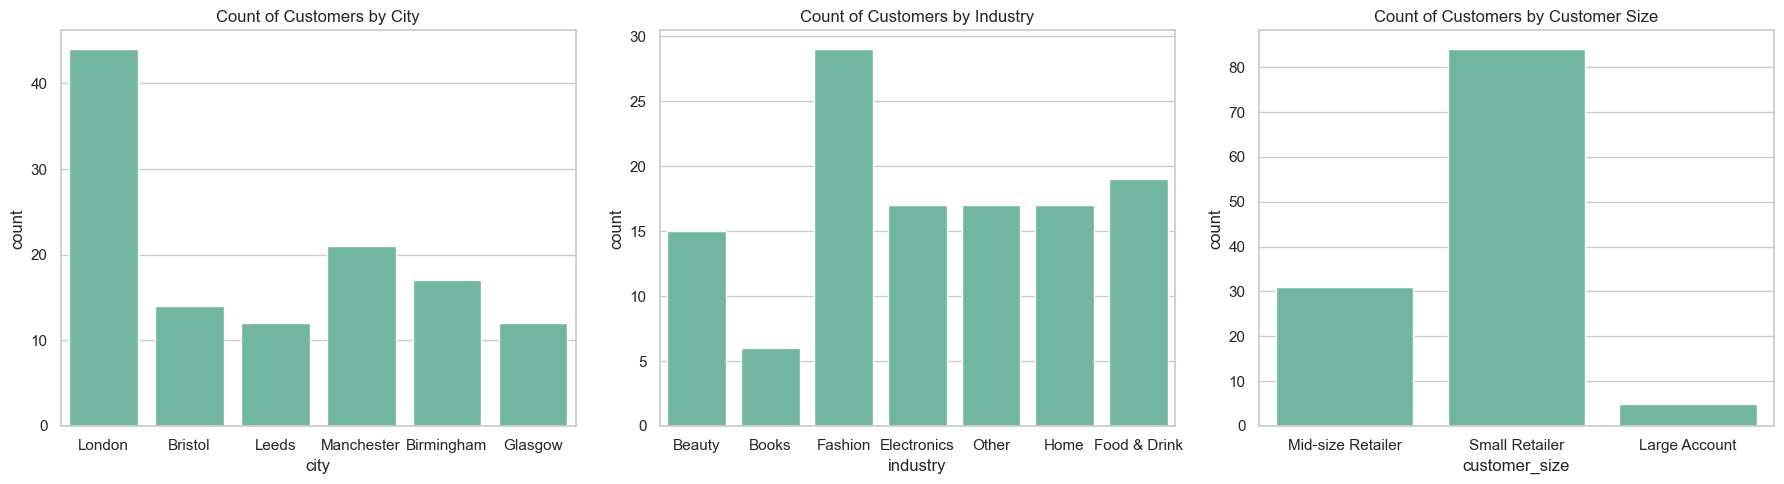

In [20]:
sns.set_style("whitegrid")
sns.set_palette("Set2")


fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.countplot(
    data=data,
    x='city',
    ax=axes[0]
)
axes[0].set_title('Count of Customers by City')

sns.countplot(
    data=data,
    x='industry',
    ax=axes[1]
)
axes[1].set_title('Count of Customers by Industry')

sns.countplot(
    data=data,
    x='customer_size',
    ax=axes[2]
)
axes[2].set_title('Count of Customers by Customer Size')

plt.tight_layout()
plt.show()







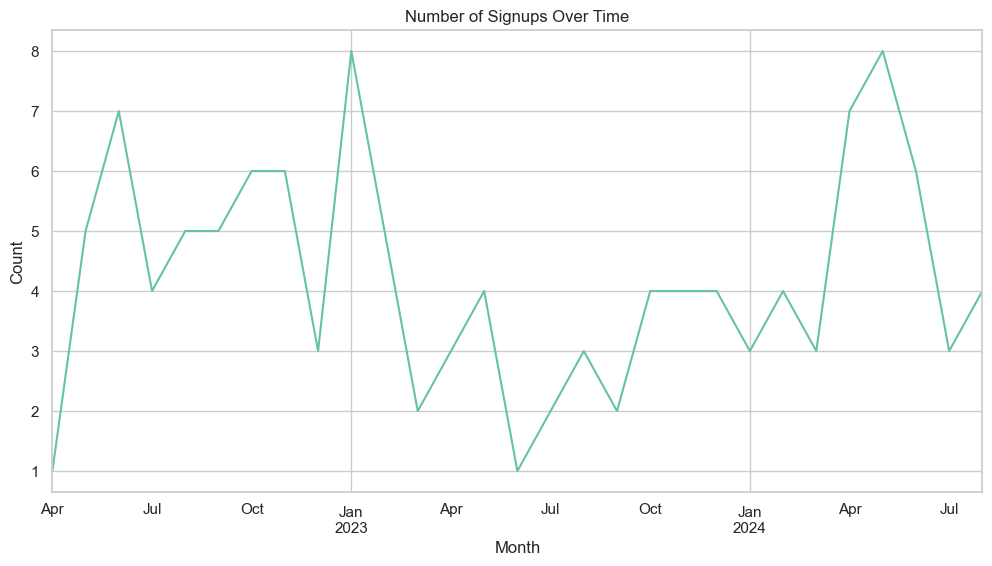

In [25]:
data['signup_date'] = pd.to_datetime(data['signup_date'])
data['signup_date'].dt.to_period('M').value_counts().sort_index().plot(kind='line', figsize=(12,6))
plt.title('Number of Signups Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()



<Axes: xlabel='customer_size', ylabel='Count'>

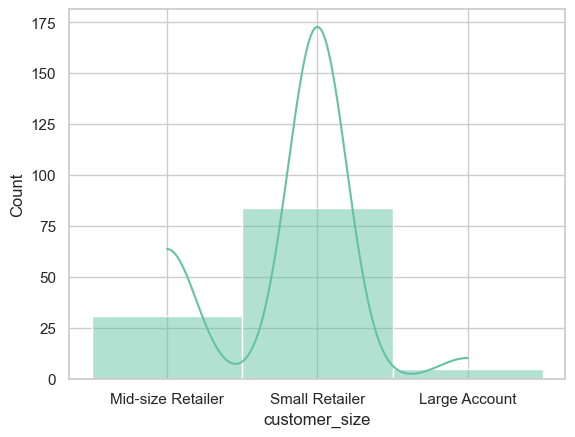

In [27]:
sns.histplot(data['customer_size'], bins=10, kde=True)

<Axes: xlabel='payment_terms_days', ylabel='Count'>

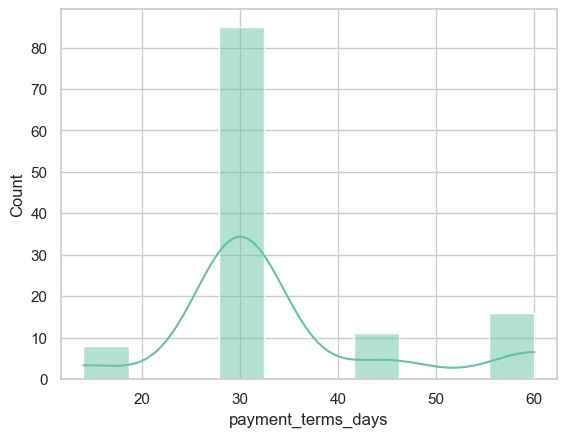

In [28]:
sns.histplot(data=data, x='payment_terms_days', bins=10, kde=True)

## couriers ##

In [29]:
data2 = pd.read_csv(r"C:\Users\tlext\Downloads\urbanshift_dataset\urbanshift_dataset\couriers.csv")
data2.head()

,courier_id,hire_date,employment_type,city,shift_pattern
0,C2000,2023-04-25,Contracted,London,Evening
1,C2001,2024-06-29,Contracted,London,Mixed
2,C2002,2024-09-28,Contracted,Birmingham,Evening
3,C2003,2024-11-14,Contracted,London,Night
4,C2004,2025-02-05,Contracted,London,Mixed


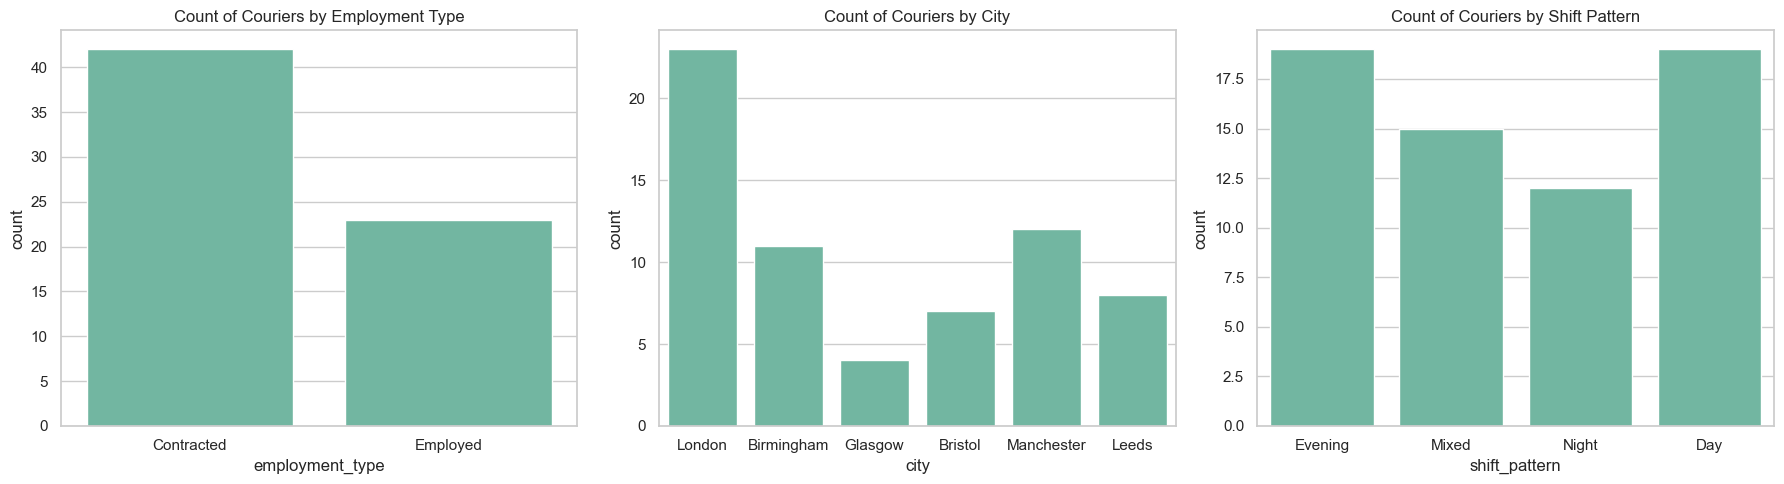

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
sns.countplot(
    data=data2,
    x='employment_type',
    ax=axes[0]
)
axes[0].set_title('Count of Couriers by Employment Type')

sns.countplot(
    data=data2,
    x='city',
    ax=axes[1]
)
axes[1].set_title('Count of Couriers by City')

sns.countplot(
    data=data2,
    x='shift_pattern',
    ax=axes[2]
)
axes[2].set_title('Count of Couriers by Shift Pattern')

plt.tight_layout()
plt.show()

## deliveries - cleaning and eda ##

In [31]:
data3 = pd.read_csv(r"C:\Users\tlext\Downloads\urbanshift_dataset\urbanshift_dataset\deliveries.csv")
data3.head()

,delivery_id,delivery_date,customer_id,courier_id,city,time_taken_minutes,delivery_status,revenue_gbp
0,D0030927,2025-03-09,CUST1021,C2006,London,82,Delivered,3.7230
1,D0053648,2024-12-01,CUST1053,C2024,Birmingham,50,Delivered,5.8500
2,D0064301,2024-11-14,CUST1075,C2029,Manchester,32,Delivered,5.2615
3,D0087733,2025-01-16,CUST1101,C2008,London,185,Delivered,6.2200
4,D0021526,2024-11-21,CUST1020,C2057,Birmingham,92,Delivered,5.9200


In [32]:
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100110 entries, 0 to 100109
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   delivery_id         100110 non-null  object 
 1   delivery_date       100110 non-null  object 
 2   customer_id         100110 non-null  object 
 3   courier_id          96106 non-null   object 
 4   city                100110 non-null  object 
 5   time_taken_minutes  100110 non-null  int64  
 6   delivery_status     100110 non-null  object 
 7   revenue_gbp         100110 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 6.1+ MB


In [33]:
# drop the duplicate rows

data3.drop_duplicates(inplace=True)

# stanrdisze city column values

data3['city'] = data3['city'].str.strip().str.title()

# given the small number of missing values in the courier_id column, we can drop those rows for simplicity

data3.dropna(subset=['courier_id'], inplace=True)

data3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 94825 entries, 0 to 100109
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   delivery_id         94825 non-null  object 
 1   delivery_date       94825 non-null  object 
 2   customer_id         94825 non-null  object 
 3   courier_id          94825 non-null  object 
 4   city                94825 non-null  object 
 5   time_taken_minutes  94825 non-null  int64  
 6   delivery_status     94825 non-null  object 
 7   revenue_gbp         94825 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 6.5+ MB


Text(0.5, 1.0, 'Number of Deliveries Over Time')

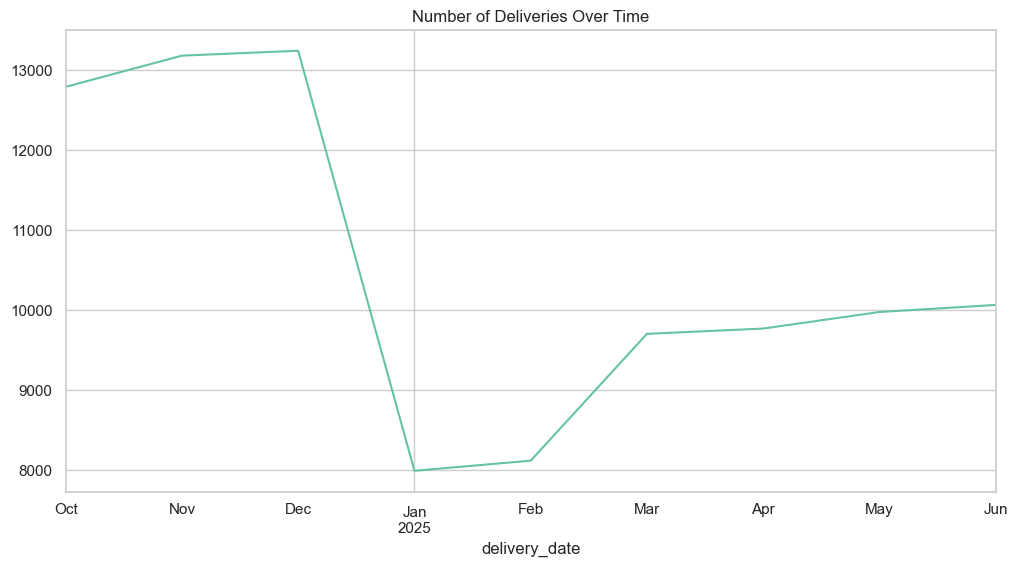

In [34]:
# deliveries over time

data3['delivery_date'] = pd.to_datetime(data3['delivery_date'])
data3['delivery_date'].dt.to_period('M').value_counts().sort_index().plot(kind='line', figsize=(12,6))
plt.title('Number of Deliveries Over Time')

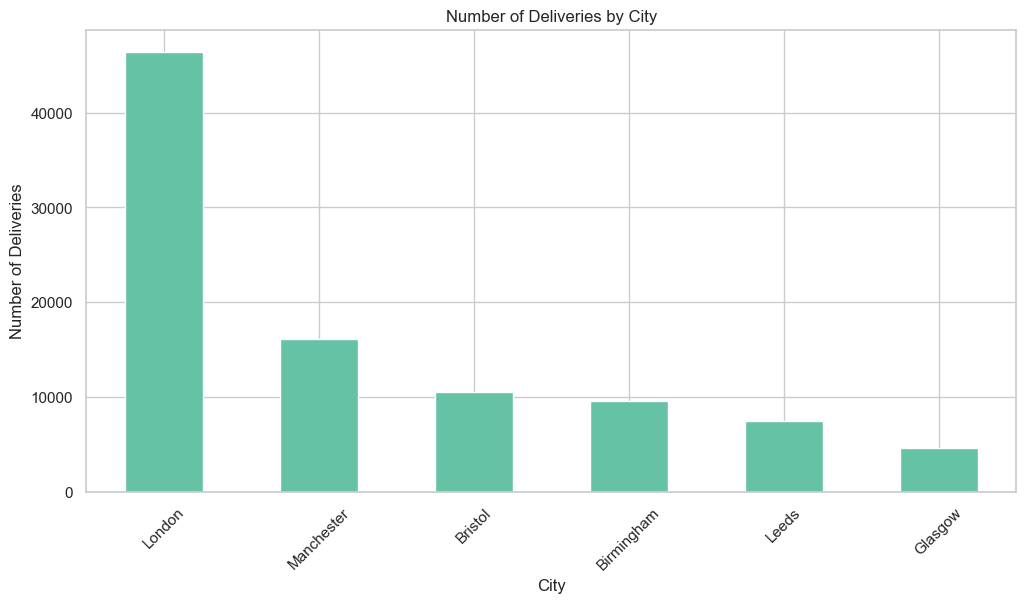

In [35]:
# deliveries by city
data3['city'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title('Number of Deliveries by City')  
plt.xlabel('City')
plt.ylabel('Number of Deliveries')
plt.xticks(rotation=45)
plt.show()

In [37]:
# looking at time taken to deliver

data3.describe()

,delivery_date,time_taken_minutes,revenue_gbp
count,94825,94825.000000,94825.000000
mean,2025-02-06 02:24:12.300553472,69.504076,5.014619
min,2024-10-01 00:00:00,20.000000,3.230000
25%,2024-11-25 00:00:00,43.000000,4.216000
50%,2025-02-01 00:00:00,61.000000,4.938500
75%,2025-04-19 00:00:00,87.000000,5.610000
max,2025-06-30 00:00:00,451.000000,7.500000
std,NaN,35.447445,1.041563


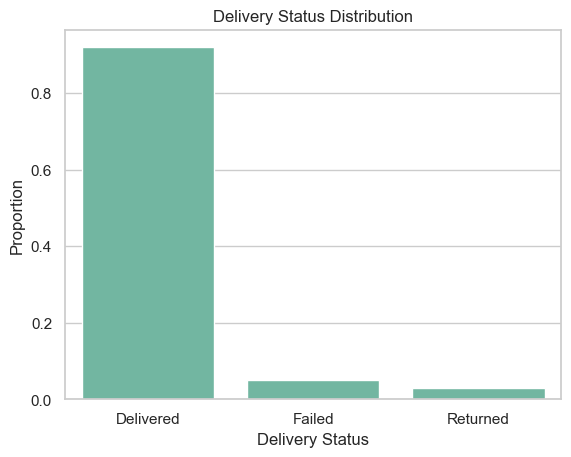

In [39]:
delivery_status_rates = data3['delivery_status'].value_counts(normalize=True)
sns.barplot(x=delivery_status_rates.index, y=delivery_status_rates.values)
plt.title('Delivery Status Distribution')
plt.xlabel('Delivery Status')
plt.ylabel('Proportion')
plt.show()

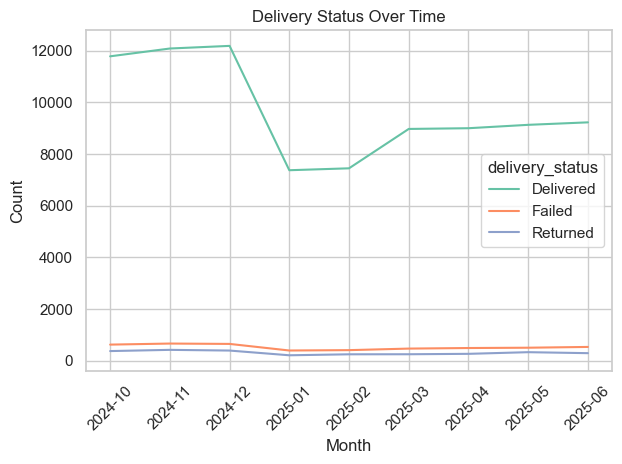

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

status_over_time = (
    data3.groupby([data3['delivery_date'].dt.to_period('M'), 'delivery_status'])
    .size()
    .reset_index(name='count')
)

status_over_time.columns = ['month', 'delivery_status', 'count']
status_over_time['month'] = status_over_time['month'].astype(str)
sns.lineplot(
    data=status_over_time,
    x='month',
    y='count',
    hue='delivery_status'
)

plt.xticks(rotation=45)
plt.title('Delivery Status Over Time')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [44]:
data3.groupby('city')[['time_taken_minutes', 'revenue_gbp']].mean()

,time_taken_minutes,revenue_gbp
city,,
Birmingham,69.931986,5.569959
Bristol,69.114405,4.675797
Glasgow,68.881707,5.483202
Leeds,69.693932,5.746083
London,69.405970,4.812632
Manchester,69.876680,5.012456


<Axes: xlabel='time_taken_minutes', ylabel='revenue_gbp'>

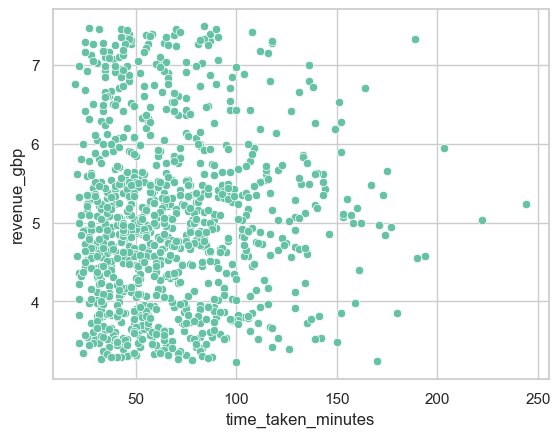

In [49]:
sns.scatterplot(data=data3.sample(1000), x='time_taken_minutes', y='revenue_gbp')

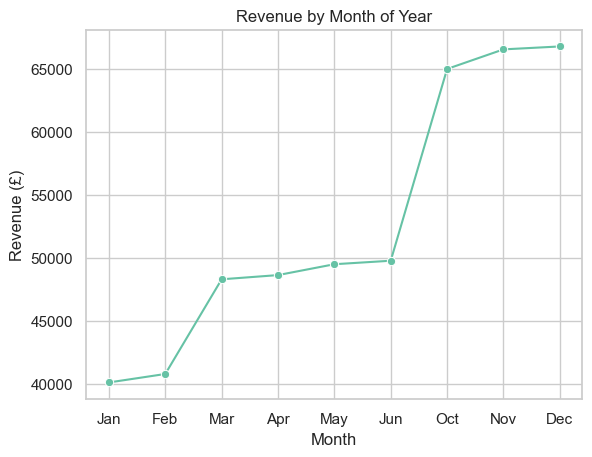

In [62]:
monthly_pattern = (
    data3.groupby(data3['delivery_date'].dt.month)['revenue_gbp']
    .sum()
    .reset_index()
)

month_names = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}

monthly_pattern['month'] = monthly_pattern['delivery_date'].map(month_names)

sns.lineplot(
    data=monthly_pattern,
    x='month',
    y='revenue_gbp',
    marker='o'
)

plt.title('Revenue by Month of Year')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.show()

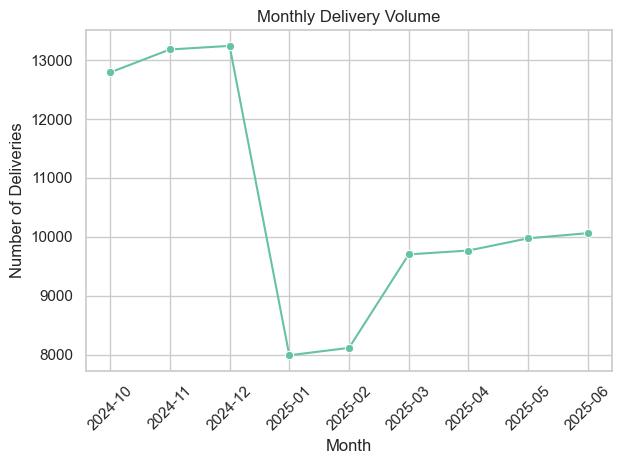

In [63]:
data3['delivery_date'] = pd.to_datetime(data3['delivery_date'])

monthly_volume = (
    data3.groupby(data3['delivery_date'].dt.to_period('M'))
    .size()
    .reset_index(name='delivery_count')
)

monthly_volume['delivery_date'] = monthly_volume['delivery_date'].astype(str)

sns.lineplot(
    data=monthly_volume,
    x='delivery_date',
    y='delivery_count',
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Delivery Volume')
plt.xlabel('Month')
plt.ylabel('Number of Deliveries')
plt.tight_layout()
plt.show()

## incidents - cleaning and eda ##

In [50]:
data4 = pd.read_csv(r"C:\Users\tlext\Downloads\urbanshift_dataset\urbanshift_dataset\incidents.csv")
data4.head()

,incident_id,delivery_id,incident_date,incident_type,resolution_status
0,INC000001,D0000006,2024-10-18,Damaged parcel,Resolved
1,INC000002,D0000007,2024-10-24,Late delivery,Resolved
2,INC000003,D0000021,2024-10-24,Customer complaint,Resolved
3,INC000004,D0000024,2024-10-07,Vehicle breakdown,Resolved
4,INC000005,D0000028,2024-10-06,Damaged parcel,Resolved


In [53]:
unmatched_incidents = data4[
    ~data4['delivery_id'].isin(data3['delivery_id'])
]

len(unmatched_incidents)
len(unmatched_incidents) / len(data4) * 100

3.836534167038857

due to low % of unmatched foreign keys, for the purposes of the inital analysis i will just remove the unmatched incidents

In [ ]:
# unmatched incidents were removed from the dataset as they were a very small % of the total incidents and would not significantly impact the analysis.


data4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21531 entries, 0 to 22388
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   incident_id        21531 non-null  object
 1   delivery_id        21531 non-null  object
 2   incident_date      21531 non-null  object
 3   incident_type      21531 non-null  object
 4   resolution_status  21531 non-null  object
dtypes: object(5)
memory usage: 1.5+ MB


In [ ]:
# joining the deliveries and incidents datasets on delivery_id to analyze

data5 = pd.merge(data3, data4, on='delivery_id', how='left')
data5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21651 entries, 0 to 21650
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   delivery_id         21651 non-null  object        
 1   delivery_date       21651 non-null  datetime64[ns]
 2   customer_id         21651 non-null  object        
 3   courier_id          21651 non-null  object        
 4   city                21651 non-null  object        
 5   time_taken_minutes  21651 non-null  int64         
 6   delivery_status     21651 non-null  object        
 7   revenue_gbp         21651 non-null  float64       
 8   incident_id         21651 non-null  object        
 9   incident_date       21651 non-null  object        
 10  incident_type       21651 non-null  object        
 11  resolution_status   21651 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 2.0+ MB


In [60]:
data5.head()

,delivery_id,delivery_date,customer_id,courier_id,city,time_taken_minutes,delivery_status,revenue_gbp,incident_id,incident_date,incident_type,resolution_status
0,D0036918,2025-03-14,CUST1022,C2026,London,104,Failed,6.6700,INC008270,2025-03-14,Damaged parcel,Resolved
1,D0053454,2025-03-06,CUST1052,C2025,London,51,Delivered,5.0600,INC011987,2025-03-06,Customer complaint,Resolved
2,D0070223,2024-11-09,CUST1079,C2022,London,77,Delivered,3.5800,INC015966,2024-11-09,Late delivery,Resolved
3,D0037453,2024-10-10,CUST1023,C2044,London,219,Returned,4.7685,INC008392,2024-10-10,Wrong address,Resolved
4,D0069108,2025-06-17,CUST1075,C2028,Manchester,61,Failed,4.7940,INC015717,17/06/2025,Customer complaint,Pending


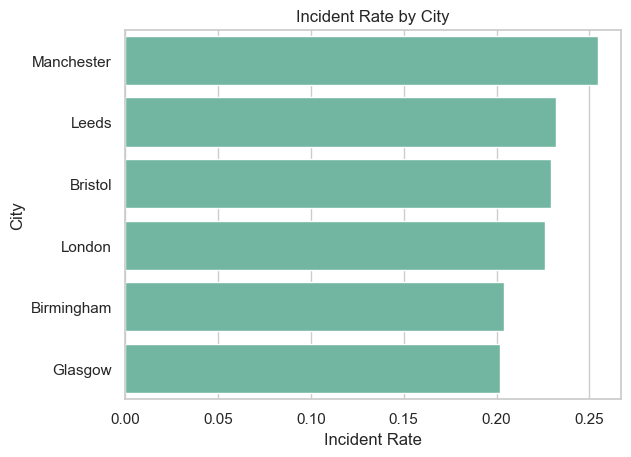

In [68]:
data3['has_incident'] = data3['delivery_id'].isin(
    data4['delivery_id']
)

city_incidents = (
    data3.groupby('city')['has_incident']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=city_incidents,
    x='has_incident',
    y='city'
)

plt.title('Incident Rate by City')
plt.xlabel('Incident Rate')
plt.ylabel('City')
plt.show()

## statistical tests ##

In [69]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(data3['city'], data3['has_incident'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-squared: {chi2}, p-value: {p_value}, Degrees of Freedom: {dof}")

Chi-squared: 114.89946432673707, p-value: 3.771232663303447e-23, Degrees of Freedom: 5


based on the chi squared test The city in which a delivery occurs appears to be related to the likelihood of an incident occurring.


A Chi-square test of independence was conducted to assess whether incident occurrence varied by city. The test found a statistically significant association between city and incident occurrence (χ²(5) = 114.90, p < 0.001). This suggests that the likelihood of a delivery experiencing an incident differs across cities. Further analysis of incident rates by city was performed to identify which locations contributed most strongly to this relationship.

In [70]:
from scipy.stats import f_oneway

groups = [
    group['time_taken_minutes']
    for _, group in data3.groupby('city')
]

f_stat, p_value = f_oneway(*groups)
print(f"F-statistic: {f_stat}, p-value: {p_value}")

F-statistic: 1.2911613923192506, p-value: 0.26436734388057503


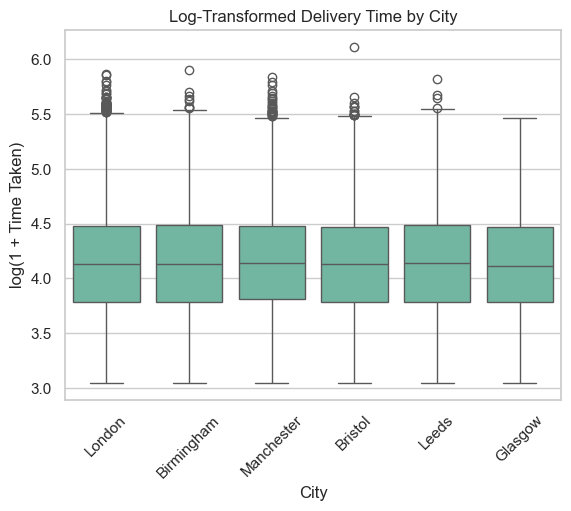

In [72]:
import numpy as np



data3['log_time_taken'] = np.log1p(data3['time_taken_minutes'])
sns.boxplot(
    data=data3,
    x='city',
    y='log_time_taken'
)

plt.xticks(rotation=45)
plt.title('Log-Transformed Delivery Time by City')
plt.xlabel('City')
plt.ylabel('log(1 + Time Taken)')
plt.show()

## focusing on the specific business questions set out in the breif ##

Operational risk: where are delivery incidents concentrated? By courier type, shift pattern and city, what drives them?

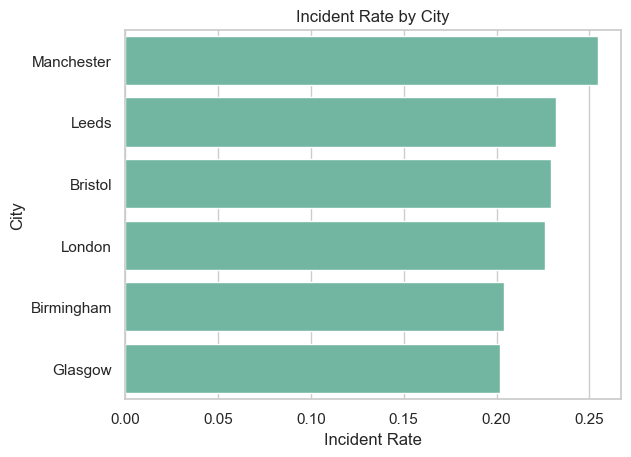

In [73]:
data3['has_incident'] = data3['delivery_id'].isin(
    data4['delivery_id']
)

city_incidents = (
    data3.groupby('city')['has_incident']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=city_incidents,
    x='has_incident',
    y='city'
)

plt.title('Incident Rate by City')
plt.xlabel('Incident Rate')
plt.ylabel('City')
plt.show()

This initial chart shows the incident rates between the cities. We see Manchester has the highest incident rate at just over 25% with Leeds, Bristol and London coming in close behind at around 22.5%. Followed by Birmingham and Glasgow with the lowest at just over 20%.

In [76]:
incident_data = data4.merge(
    data3[['delivery_id', 'courier_id']],
    on='delivery_id',
    how='left'
).merge(
    data2[['courier_id', 'shift_pattern']],
    on='courier_id',
    how='left'
)

In [77]:
delivery_data = data3.merge(
    data2[['courier_id', 'shift_pattern']],
    on='courier_id',
    how='left'
)

In [79]:
delivery_data['has_incident'] = delivery_data['delivery_id'].isin(
    data4['delivery_id']
)

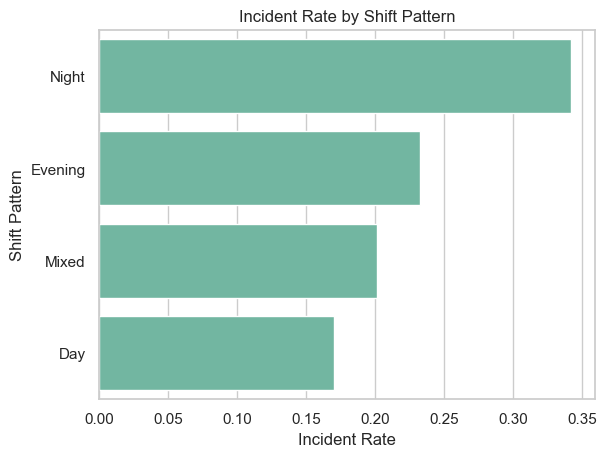

In [80]:
shift_incidents = (
    delivery_data.groupby('shift_pattern')['has_incident']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(
    data=shift_incidents,
    x='has_incident',
    y='shift_pattern'
)

plt.title('Incident Rate by Shift Pattern')
plt.xlabel('Incident Rate')
plt.ylabel('Shift Pattern')
plt.show()

We now see that night shifts have the highest incident rate by over 10%. Night shifts have an incident rate of just under 35% with evenings coming in at around 23%, mixed at 20% and day shifts coming in at around 17%.

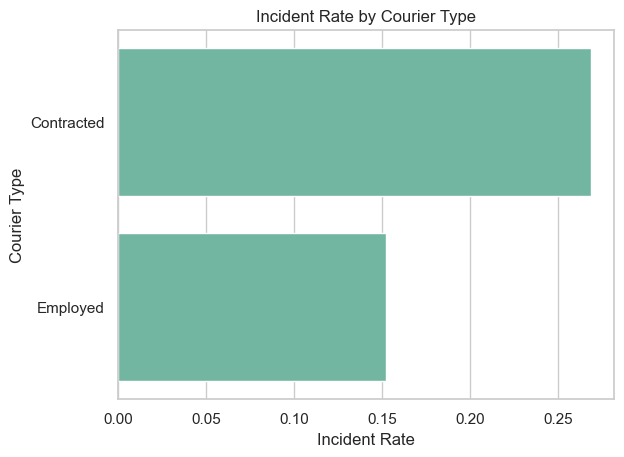

In [81]:
delivery_data = data3.merge(
    data2[['courier_id', 'employment_type']],
    on='courier_id',
    how='left'
)

delivery_data['has_incident'] = delivery_data['delivery_id'].isin(
    data4['delivery_id']
)

courier_incidents = (
    delivery_data.groupby('employment_type')['has_incident']
    .mean()
    .reset_index()
)

sns.barplot(
    data=courier_incidents,
    x='has_incident',
    y='employment_type'
)

plt.title('Incident Rate by Courier Type')
plt.xlabel('Incident Rate')
plt.ylabel('Courier Type')
plt.show()

This figure shows us very interesting results - contracted employees have an incident rate over 10% greater than regular employees. Contracters come in at an incident rate of around 27% compared to just over 15% for non cointractors

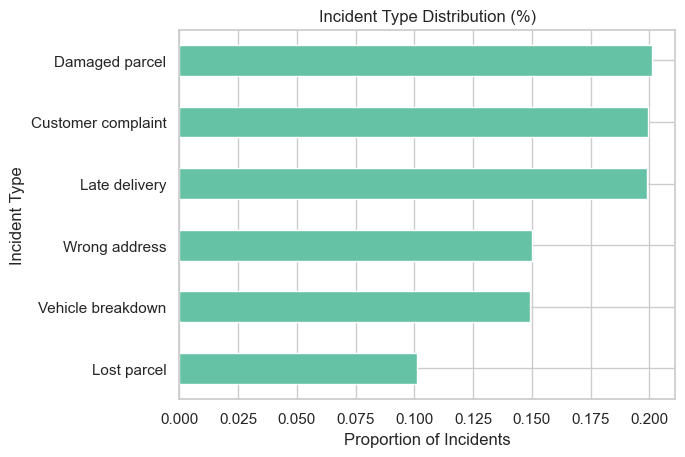

In [83]:
incident_dist = (
    data4['incident_type']
    .value_counts(normalize=True)
    .sort_values(ascending=True)
)


incident_dist.plot(kind='barh')

plt.title('Incident Type Distribution (%)')
plt.xlabel('Proportion of Incidents')
plt.ylabel('Incident Type')
plt.show()